# DataCo Inventory Analytics — working notebook

**Business question:** Across this catalog, where is working capital trapped in slow-moving inventory, and how should reorder policies change to free cash without dropping below a 95% service level?

Flow: raw CSV → audit (this section) → DuckDB SQL aggregation → pandas per-SKU stats → 4 layers → `outputs/sku_metrics.csv`.

---
## Audit the raw data

Goal: confirm the data is trustworthy before aggregating. Row count, date range, nulls on the columns every downstream metric depends on, and a first look at demand shape.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = "../data/DataCoSupplyChainDataset.csv"

# latin-1: the file has non-UTF-8 bytes and errors under the default encoding
raw = pd.read_csv(RAW, encoding="latin-1")
print(f"rows: {len(raw):,}   columns: {raw.shape[1]}")
raw.head(3)

rows: 180,519   columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [2]:
# The columns every downstream metric depends on.
KEY_COLS = [
    "Product Card Id",              # the SKU key
    "Order Item Quantity",          # demand
    "order date (DateOrders)",      # time axis
    "Product Price",                # value / ABC / EOQ
    "Days for shipping (real)",     # lead time -> safety stock
]

raw[KEY_COLS].info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Product Card Id           180519 non-null  int64  
 1   Order Item Quantity       180519 non-null  int64  
 2   order date (DateOrders)   180519 non-null  str    
 3   Product Price             180519 non-null  float64
 4   Days for shipping (real)  180519 non-null  int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 9.4 MB


In [3]:
# Null check on the key columns
nulls = raw[KEY_COLS].isna().sum()
print("nulls in key columns:")
print(nulls)
assert nulls.sum() == 0, "key columns contain nulls — handle before aggregating"

nulls in key columns:
Product Card Id             0
Order Item Quantity         0
order date (DateOrders)     0
Product Price               0
Days for shipping (real)    0
dtype: int64


In [4]:
# Date range. Source format looks like  M/D/YYYY H:MM  e.g. 1/31/2018 22:56
order_date = pd.to_datetime(raw["order date (DateOrders)"], format="%m/%d/%Y %H:%M")
print("earliest order:", order_date.min())
print("latest order:  ", order_date.max())
print("span (months): ", (order_date.max().to_period("M") - order_date.min().to_period("M")).n + 1)
print("unparsed dates:", order_date.isna().sum())

earliest order: 2015-01-01 00:00:00
latest order:   2018-01-31 23:38:00
span (months):  37
unparsed dates: 0


In [5]:
# Scale of the catalog + basic distributions
print("distinct SKUs (Product Card Id):", raw["Product Card Id"].nunique())
print()
print(raw["Order Item Quantity"].describe())
print()
print(raw["Product Price"].describe())
print()
print("Days for shipping (real):")
print(raw["Days for shipping (real)"].describe())

distinct SKUs (Product Card Id): 118

count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: Order Item Quantity, dtype: float64

count    180519.000000
mean        141.232550
std         139.732492
min           9.990000
25%          50.000000
50%          59.990002
75%         199.990005
max        1999.989990
Name: Product Price, dtype: float64

Days for shipping (real):
count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Days for shipping (real), dtype: float64


top 10 SKUs by total units:
Product Card Id  Product Name                                 
365              Perfect Fitness Perfect Rip Deck                 73698
502              Nike Men's Dri-FIT Victory Golf Polo             62956
1014             O'Brien Men's Neoprene Life Vest                 57803
191              Nike Men's Free 5.0+ Running Shoe                36680
627              Under Armour Girls' Toddler Spine Surge Runni    31735
403              Nike Men's CJ Elite 2 TD Football Cleat          22246
1004             Field & Stream Sportsman 16 Gun Fire Safe        17325
1073             Pelican Sunstream 100 Kayak                      15500
957              Diamondback Women's Serene Classic Comfort Bi    13729
977              ENO Atlas Hammock Straps                           998
Name: Order Item Quantity, dtype: int64


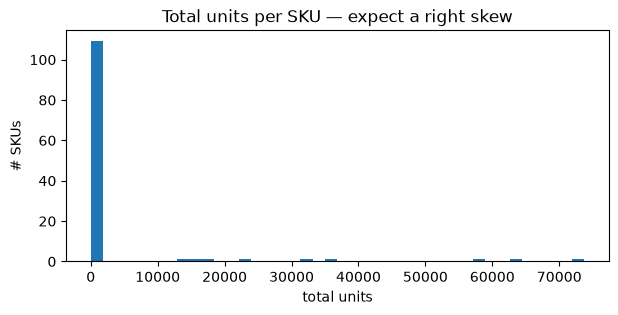

In [6]:
# Do the top sellers make sense, and is total demand right-skewed?
demand_by_sku = (
    raw.groupby(["Product Card Id", "Product Name"])["Order Item Quantity"]
    .sum()
    .sort_values(ascending=False)
)
print("top 10 SKUs by total units:")
print(demand_by_sku.head(10))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(demand_by_sku.values, bins=40)
ax.set_title("Total units per SKU — expect a right skew")
ax.set_xlabel("total units")
ax.set_ylabel("# SKUs")
plt.show()

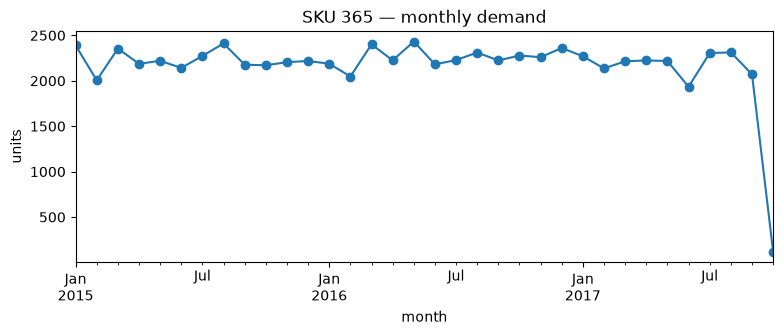

In [7]:
# One SKU's monthly demand series (spot-check the time axis behaves)
top_sku = demand_by_sku.index[0][0]
one = raw.loc[raw["Product Card Id"] == top_sku].copy()
one["month"] = pd.to_datetime(one["order date (DateOrders)"], format="%m/%d/%Y %H:%M").dt.to_period("M")
monthly = one.groupby("month")["Order Item Quantity"].sum()

fig, ax = plt.subplots(figsize=(9, 3))
monthly.plot(ax=ax, marker="o")
ax.set_title(f"SKU {top_sku} — monthly demand")
ax.set_ylabel("units")
plt.show()

### Audit findings

- **Rows / columns:** 180,519 rows × 53 columns
- **Date range:** 2015-01-01 to 2018-01-31 (37 months)
- **Distinct SKUs:** 118
- **Nulls in key columns:** none — 0 across all 5 (`Product Card Id`,
  `Order Item Quantity`, `order date (DateOrders)`, `Product Price`,
  `Days for shipping (real)`)
- **Demand shape:** right-skewed — a small number of SKUs carry most of the
  unit volume. This is the ABC/Pareto result already visible in the raw data.
- **Anything odd:**
  - `Order Item Quantity` ranges 1–5, no zeros or negatives — clean.
  - `Product Price` ranges $9.99–$1999.99, no zeros — clean.
  - `Days for shipping (real)` ranges only 0–6 days — a very tight spread, so
    σ(lead time) will be small. Safety stock will be driven mostly by *demand*
    variability, not lead-time variability.
  - ~19% of orders (33,784) have a negative `Benefit per order`. Kept on purpose
    — it's the signal for prioritising which SKUs to fix first.
  - Only ~1,818 SKU-months are populated out of a possible 118 × 37 ≈ 4,366, so
    many SKUs have months with zero sales. **Decision needed** before computing
    σ(demand): treat missing months as zero-demand, or ignore them? This changes
    the safety-stock numbers.


---
## Build the per-SKU demand profile

`src/extract.py` gave us demand at **SKU x month** grain. The four analytical layers
need **one row per SKU** with demand and lead-time statistics already computed.

Steps:
1. read the two aggregated CSVs
2. for each SKU, rebuild its monthly series between its first and last sale month,
   filling gap months with **0** (a month with no orders is demand = 0, not missing)
3. collapse that padded series to mean / std of monthly demand
4. flag SKUs with too little history for a trustworthy std
5. join the per-SKU lead-time stats
6. save `outputs/sku_demand_profile.csv` — the per-SKU deliverable


In [8]:
import numpy as np

demand_m = pd.read_csv("../outputs/demand_by_sku_month.csv", parse_dates=["month"])
leadtime = pd.read_csv("../outputs/leadtime_by_sku.csv")

print("demand_by_sku_month:", demand_m.shape)
print("leadtime_by_sku:    ", leadtime.shape)
demand_m.head()

demand_by_sku_month: (1818, 6)
leadtime_by_sku:     (118, 4)


,sku,product_name,month,units,order_lines,avg_price
0,19,Nike Men's Fingertrap Max Training Shoe,2017-04-01,2.0,2,124.989998
1,19,Nike Men's Fingertrap Max Training Shoe,2017-05-01,13.0,13,124.989998
2,19,Nike Men's Fingertrap Max Training Shoe,2017-06-01,13.0,13,124.989998
3,19,Nike Men's Fingertrap Max Training Shoe,2017-07-01,15.0,15,124.989998
4,19,Nike Men's Fingertrap Max Training Shoe,2017-08-01,17.0,17,124.989998


In [9]:
# Below this many months of history, std(monthly demand) is not trustworthy.
MIN_MONTHS = 6


def sku_profile(g):
    """Collapse one SKU's monthly rows to a single profile row.

    Gap months between the SKU's first and last sale are filled with 0 so the
    std reflects the real on/off lumpiness of demand. Months before the first
    sale / after the last are NOT added (the product did not exist then)."""
    s = g.set_index("month")["units"].sort_index()
    full = pd.period_range(s.index.min().to_period("M"),
                           s.index.max().to_period("M"), freq="M").to_timestamp()
    units = s.reindex(full, fill_value=0)
    return pd.Series({
        "product_name": g["product_name"].iloc[0],
        "avg_price": g["avg_price"].mean(),
        "n_months": len(units),
        "total_units": units.sum(),
        "mean_monthly_demand": units.mean(),
        "std_monthly_demand": units.std(ddof=1),   # NaN when n_months == 1
    })


profile = (
    demand_m.groupby("sku", group_keys=True)
    .apply(sku_profile, include_groups=False)
    .reset_index()
)
profile["insufficient_history"] = profile["n_months"] < MIN_MONTHS
profile.head()

,sku,product_name,avg_price,n_months,total_units,mean_monthly_demand,std_monthly_demand,insufficient_history
0,19,Nike Men's Fingertrap Max Training Shoe,124.989998,6,64.0,10.666667,6.153590,False
1,24,Elevation Training Mask 2.0,79.989998,6,231.0,38.500000,23.939507,False
2,35,adidas Brazuca 2014 Official Match Ball,159.990006,6,65.0,10.833333,4.622409,False
3,37,adidas Kids' F5 Messi FG Soccer Cleat,34.990002,28,781.0,27.892857,11.911213,False
4,44,adidas Men's F10 Messi TRX FG Soccer Cleat,59.990002,28,939.0,33.535714,11.026843,False


In [10]:
sku_demand_profile = profile.merge(
    leadtime[["sku", "avg_lead_time_days", "std_lead_time_days"]],
    on="sku", how="left",
)

out_path = "../outputs/sku_demand_profile.csv"
sku_demand_profile.to_csv(out_path, index=False)

print("saved", sku_demand_profile.shape, "->", out_path)
print()
print("insufficient_history (n_months <", MIN_MONTHS, "):")
print(sku_demand_profile["insufficient_history"].value_counts())
print()
print("rows with NaN std_monthly_demand (1-month SKUs):",
      sku_demand_profile["std_monthly_demand"].isna().sum())
sku_demand_profile.sort_values("total_units", ascending=False).head(10)

saved (118, 10) -> ../outputs/sku_demand_profile.csv

insufficient_history (n_months < 6 ):
insufficient_history
False    85
True     33
Name: count, dtype: int64

rows with NaN std_monthly_demand (1-month SKUs): 9


,sku,product_name,avg_price,n_months,total_units,mean_monthly_demand,std_monthly_demand,insufficient_history,avg_lead_time_days,std_lead_time_days
35,365,Perfect Fitness Perfect Rip Deck,59.990002,34,73698.0,2167.588235,378.737385,False,3.506384,1.631457
37,502,Nike Men's Dri-FIT Victory Golf Polo,50.000000,34,62956.0,1851.647059,329.715937,False,3.484716,1.620296
97,1014,O'Brien Men's Neoprene Life Vest,49.980000,34,57803.0,1700.088235,306.661729,False,3.495751,1.627167
15,191,Nike Men's Free 5.0+ Running Shoe,99.989998,34,36680.0,1078.823529,200.050519,False,3.493960,1.620662
44,627,Under Armour Girls' Toddler Spine Surge Runni,39.990002,34,31735.0,933.382353,172.346904,False,3.494584,1.629719
36,403,Nike Men's CJ Elite 2 TD Football Cleat,129.990006,34,22246.0,654.294118,114.856044,False,3.501259,1.617746
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,34,17325.0,509.558824,90.182371,False,3.502049,1.614683
99,1073,Pelican Sunstream 100 Kayak,199.990006,34,15500.0,455.882353,80.602566,False,3.483032,1.623083
92,957,Diamondback Women's Serene Classic Comfort Bi,299.980011,34,13729.0,403.794118,71.108871,False,3.498215,1.626472
93,977,ENO Atlas Hammock Straps,29.990000,28,998.0,35.642857,10.705534,False,3.455108,1.651368


### Modelling choices recorded here

- **Gap months = 0 demand.** Filled only *between* each SKU's first and last sale.
  On this data that touches ~10 SKUs by 1 month each, so the numeric effect is
  small, but it is the defensible method and matters more once the catalog grows.
- **`MIN_MONTHS = 6`.** 33 of 118 SKUs fall below this and are flagged
  `insufficient_history`; 9 of those have only one month of sales, so their
  `std_monthly_demand` is `NaN`. In the safety-stock layer these SKUs get a class-level fallback
  sigma rather than a per-SKU one, and are kept out of the headline
  trapped-cash number.
- **Stockout censoring (known limitation).** A zero-sales month could mean
  "no demand" or "we were out of stock". The dataset has no on-hand column, so
  the two cannot be told apart; zeros are treated as true zero demand.

Deliverable: `outputs/sku_demand_profile.csv`.


---
# The analytical layers

Each layer is a function in `src/inventory.py`; the notebook calls them and
inspects the result. Assumptions (`S`, `H_RATE`, service levels) live at the top
of that module.

## Layer 1 — implied turnover, days-of-supply, velocity tier

No on-hand column exists, so average inventory is derived from the sawtooth
cycle-stock model: average cycle stock = EOQ / 2. Because that proxy assumes
cost-optimal ordering, the turns figure is a **best-case benchmark** — it ranks
SKUs by relative velocity, it does not prove overstocking. Output is a relative
`velocity_tier` (Slow / Medium / Fast by tercile), not an absolute verdict.


In [11]:
import sys
sys.path.insert(0, "..")   # so "src" is importable when running from notebooks/

from src.inventory import annualize_demand, layer1_turnover, S, H_RATE

profile = pd.read_csv("../outputs/sku_demand_profile.csv")

l1 = layer1_turnover(annualize_demand(profile))
print(f"assumptions in use:  S = ${S:.0f} / order,  H_RATE = {H_RATE:.0%} of price / year")
l1[["sku", "product_name", "avg_price", "annual_demand",
    "implied_eoq", "implied_turns", "implied_days_of_supply",
    "velocity_tier", "slow_mover"]].head()

assumptions in use:  S = $75 / order,  H_RATE = 25% of price / year


,sku,product_name,avg_price,annual_demand,implied_eoq,implied_turns,implied_days_of_supply,velocity_tier,slow_mover
0,19,Nike Men's Fingertrap Max Training Shoe,124.989998,128.000000,24.788085,10.327542,35.342387,Slow,True
1,24,Elevation Training Mask 2.0,79.989998,462.000000,58.867931,15.696152,23.254107,Medium,False
2,35,adidas Brazuca 2014 Official Match Ball,159.990006,130.000000,22.080092,11.775313,30.997052,Medium,False
3,37,adidas Kids' F5 Messi FG Soccer Cleat,34.990002,334.714286,75.760140,8.836158,41.307545,Slow,True
4,44,adidas Men's F10 Messi TRX FG Soccer Cleat,59.990002,402.428571,63.442544,12.686394,28.770980,Medium,False


In [12]:
# What each velocity tier looks like
tier_summary = (
    l1.groupby("velocity_tier", observed=True)
      .agg(skus=("sku", "size"),
           median_turns=("implied_turns", "median"),
           median_days_of_supply=("implied_days_of_supply", "median"),
           median_annual_value=("annual_demand_value", "median"),
           total_annual_value=("annual_demand_value", "sum"))
      .round(0)
)
print(tier_summary)
print()
print("slowest 8 SKUs by implied turns:")
print(l1.sort_values("implied_turns")
        [["sku", "product_name", "avg_price", "annual_demand",
          "implied_turns", "implied_days_of_supply"]]
        .head(8).to_string(index=False))

               skus  median_turns  median_days_of_supply  median_annual_value  \
velocity_tier                                                                   
Slow             40           8.0                   45.0               9693.0   
Medium           39          13.0                   28.0              26353.0   
Fast             39          46.0                    8.0             317582.0   

               total_annual_value  
velocity_tier                      
Slow                     410267.0  
Medium                  1063121.0  
Fast                   23838401.0  

slowest 8 SKUs by implied turns:
 sku                         product_name  avg_price  annual_demand  implied_turns  implied_days_of_supply
 775              Clicgear 8.0 Shoe Brush       9.99     380.571429       5.034487               72.499943
 792        Hirzl Men's Hybrid Golf Glove      14.99     370.285714       6.083082               60.002480
 793      Hirzl Women's Hybrid Golf Glove      14.99     38

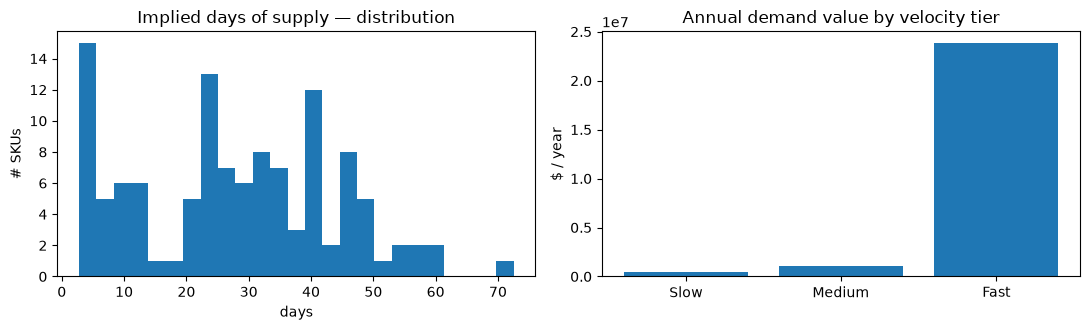

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))

ax[0].hist(l1["implied_days_of_supply"], bins=25)
ax[0].set_title("Implied days of supply — distribution")
ax[0].set_xlabel("days")
ax[0].set_ylabel("# SKUs")

order = ["Slow", "Medium", "Fast"]
ax[1].bar(order, [l1.loc[l1.velocity_tier == t, "annual_demand_value"].sum() for t in order])
ax[1].set_title("Annual demand value by velocity tier")
ax[1].set_ylabel("$ / year")

plt.tight_layout()
plt.show()

### What Layer 1 says

- Split into 40 Slow / 39 Medium / 39 Fast SKUs by tercile of implied turns.
- The **Slow tier** is low-price, low-volume accessories: median ~45 days of
  supply and only ~$10k annual demand value each. The **Fast tier** moves
  ~$300k+ each and clears stock in ~8 days.
- `slow_mover = velocity_tier == "Slow"` — carried forward; Layer 5 crosses it
  against ABC class to find where buffer cash is misallocated.
- **Caveat repeated:** turns here assume EOQ ordering, so they are a floor on how
  well stock *could* move, not a measurement of how it actually moves.


## Layer 2 — ABC classification

Rank SKUs by `annual_demand_value` (price x annual demand), sort descending,
and cut by cumulative share of total value:

- **A** = cumulative <= 80%
- **B** = cumulative <= 95%
- **C** = the rest

Cut points are the standard 80/95 default (`ABC_CUTOFFS` in `src/inventory.py`).


In [14]:
from src.inventory import layer2_abc, ABC_CUTOFFS

abc = layer2_abc(l1)

class_summary = (
    abc.groupby("abc_class")
       .agg(skus=("sku", "size"),
            total_annual_value=("annual_demand_value", "sum"))
)
class_summary["pct_of_skus"] = class_summary["skus"] / len(abc)
class_summary["pct_of_value"] = class_summary["total_annual_value"] / abc["annual_demand_value"].sum()
class_summary = class_summary.round({"pct_of_skus": 3, "pct_of_value": 3})
print(class_summary)

           skus  total_annual_value  pct_of_skus  pct_of_value
abc_class                                                     
A            16        2.002069e+07        0.136         0.791
B            28        4.011698e+06        0.237         0.158
C            74        1.279403e+06        0.627         0.051


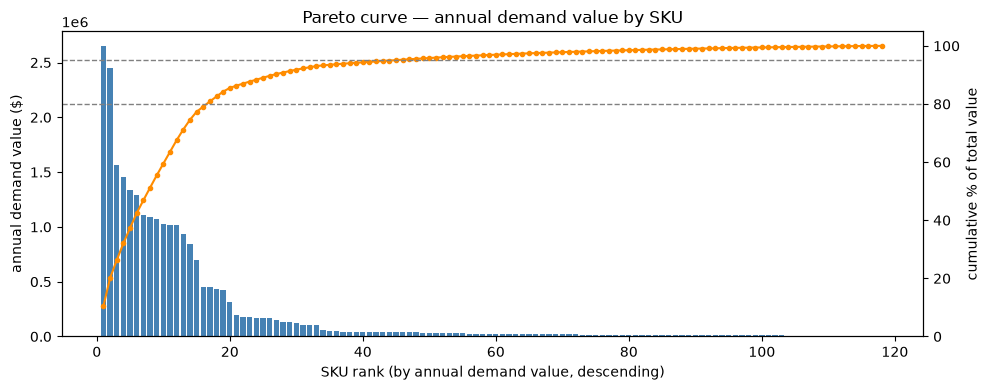

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(abc["value_rank"], abc["annual_demand_value"], color="steelblue")
ax1.set_xlabel("SKU rank (by annual demand value, descending)")
ax1.set_ylabel("annual demand value ($)")
ax1.set_title("Pareto curve — annual demand value by SKU")

ax2 = ax1.twinx()
ax2.plot(abc["value_rank"], abc["cumulative_pct"] * 100, color="darkorange", marker=".")
ax2.set_ylabel("cumulative % of total value")
ax2.set_ylim(0, 105)
ax2.axhline(ABC_CUTOFFS["A"] * 100, color="gray", linestyle="--", linewidth=1)
ax2.axhline(ABC_CUTOFFS["B"] * 100, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [16]:
# Cross-check against Layer 1: are slow movers concentrated in class C, as expected?
pd.crosstab(abc["abc_class"], abc["velocity_tier"], margins=True)

velocity_tier,Slow,Medium,Fast,All
abc_class,,,,
A,0,0,16,16
B,0,5,23,28
C,40,34,0,74
All,40,39,39,118


### What Layer 2 says

- **16 SKUs (14% of the catalog) are class A** — 79% of annual demand value.
- **28 SKUs (24%) are class B** — 16% of value.
- **74 SKUs (63%) are class C** — 5% of value.
- A steep Pareto curve: value is heavily concentrated in a small set of
  high-price / high-volume items (laptops, safes, bikes), while the long tail
  of low-price accessories contributes very little revenue.

**Important finding from the cross-tab with Layer 1's velocity tier:** there is
**zero overlap** — every class-A SKU is Fast, every Slow SKU is class C, nothing
crosses over. That is not a coincidence, it is algebra: under the EOQ/2 proxy,
```implied_turns = sqrt(2 * H_RATE / S) * sqrt(annual_demand_value)```
so implied turnover is just a monotonic transform of ABC value — the two layers
are measuring the *same underlying signal* two different ways, not independent
things. **Consequence:** Layer 1 vs. Layer 2 cannot be the mismatch analysis —
by construction they will always agree. The real punchline (over/under-buffered
stock) has to compare ABC class against something Layer 1 does not capture:
the actual safety-stock / reorder-point behaviour from Layer 4.


## Layer 3 — economic order quantity (EOQ)

`eoq = sqrt(2 * D * S / H_unit)` — the order size that minimises annual ordering
+ holding cost. (Same number as Layer 1's `implied_eoq`; here it is priced as a
policy rather than used as an inventory proxy.)

**Data limitation:** the dataset is customer sales, not the business's own
purchase orders, so real supplier order sizing is not observable. The comparison
below is against a common default policy — **reorder monthly** (order size = one
month of demand) — not against actuals.


In [17]:
from src.inventory import layer3_eoq

l3 = layer3_eoq(abc)

print("catalogue-wide annual ordering + holding cost")
print(f"  at EOQ            : ${l3['eoq_annual_cost'].sum():>12,.0f}")
print(f"  monthly baseline  : ${l3['monthly_annual_cost'].sum():>12,.0f}")
print(f"  saving from EOQ   : ${l3['eoq_saving_vs_monthly'].sum():>12,.0f}"
      f"  ({l3['eoq_saving_vs_monthly'].sum() / l3['monthly_annual_cost'].sum():.0%})")
print(f"  median per-SKU saving: {l3['eoq_saving_pct'].median():.1%}")

l3[["sku", "product_name", "abc_class", "annual_demand", "eoq",
    "eoq_orders_per_year", "eoq_cycle_days", "eoq_saving_vs_monthly",
    "eoq_saving_pct"]].head()

catalogue-wide annual ordering + holding cost
  at EOQ            : $     224,647
  monthly baseline  : $     369,864
  saving from EOQ   : $     145,217  (39%)
  median per-SKU saving: 26.3%


,sku,product_name,abc_class,annual_demand,eoq,eoq_orders_per_year,eoq_cycle_days,eoq_saving_vs_monthly,eoq_saving_pct
0,1351,Dell Laptop,A,1768.000000,26.593232,66.483081,5.490119,18552.537917,0.650396
1,1004,Field & Stream Sportsman 16 Gun Fire Safe,A,6114.705882,95.773259,63.845649,5.716913,16799.820653,0.636920
2,365,Perfect Fitness Perfect Rip Deck,A,26011.058824,510.052880,50.996789,7.157313,9504.684459,0.554073
3,957,Diamondback Women's Serene Classic Comfort Bi,A,4845.529412,98.446455,49.219948,7.415693,8658.278288,0.539750
4,1353,Porcelain crafts,A,2904.000000,61.446547,47.260589,7.723137,7770.682014,0.522934


In [18]:
# Where do the EOQ savings sit?
saving_by_class = (
    l3.groupby("abc_class")
      .agg(skus=("sku", "size"),
           eoq_cost=("eoq_annual_cost", "sum"),
           monthly_cost=("monthly_annual_cost", "sum"),
           saving=("eoq_saving_vs_monthly", "sum"))
      .round(0)
)
saving_by_class["saving_pct"] = (saving_by_class["saving"]
                                 / saving_by_class["monthly_cost"]).round(3)
print(saving_by_class)
print()
print("largest single-SKU savings:")
print(l3.sort_values("eoq_saving_vs_monthly", ascending=False)
        [["sku", "product_name", "abc_class", "eoq", "monthly_order_size",
          "eoq_saving_vs_monthly"]].head(8).to_string(index=False))

           skus  eoq_cost  monthly_cost    saving  saving_pct
abc_class                                                    
A            16  107200.0      222949.0  115749.0       0.519
B            28   59927.0       66989.0    7061.0       0.105
C            74   57520.0       79927.0   22408.0       0.280

largest single-SKU savings:
 sku                                  product_name abc_class        eoq  monthly_order_size  eoq_saving_vs_monthly
1351                                   Dell Laptop         A  26.593232          147.333333           18552.537917
1004     Field & Stream Sportsman 16 Gun Fire Safe         A  95.773259          509.558824           16799.820653
 365              Perfect Fitness Perfect Rip Deck         A 510.052880         2167.588235            9504.684459
 957 Diamondback Women's Serene Classic Comfort Bi         A  98.446455          403.794118            8658.278288
1353                              Porcelain crafts         A  61.446547          242.0

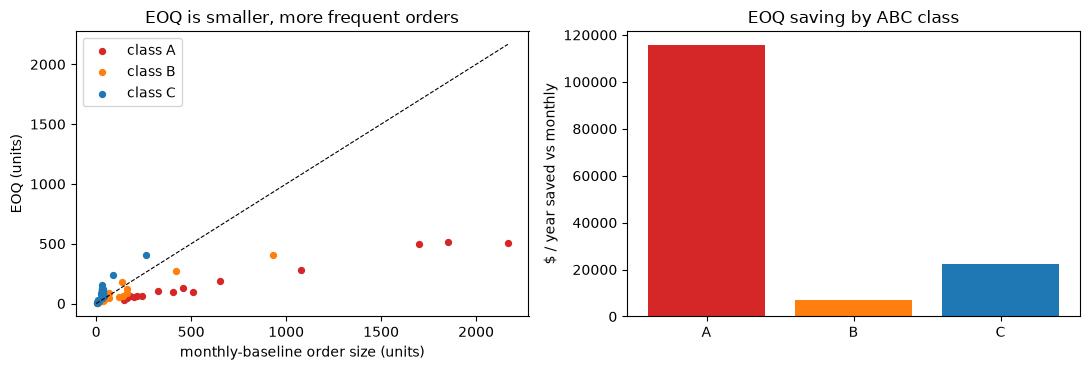

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

colours = {"A": "tab:red", "B": "tab:orange", "C": "tab:blue"}
for cls, grp in l3.groupby("abc_class"):
    ax[0].scatter(grp["monthly_order_size"], grp["eoq"], s=18,
                  label=f"class {cls}", color=colours[cls])
lim = max(l3["monthly_order_size"].max(), l3["eoq"].max())
ax[0].plot([0, lim], [0, lim], "k--", linewidth=0.8)
ax[0].set_xlabel("monthly-baseline order size (units)")
ax[0].set_ylabel("EOQ (units)")
ax[0].set_title("EOQ is smaller, more frequent orders")
ax[0].legend()

order = ["A", "B", "C"]
ax[1].bar(order, [l3.loc[l3.abc_class == c, "eoq_saving_vs_monthly"].sum() for c in order],
          color=[colours[c] for c in order])
ax[1].set_ylabel("$ / year saved vs monthly")
ax[1].set_title("EOQ saving by ABC class")

plt.tight_layout()
plt.show()

### What Layer 3 says

- Following EOQ instead of a monthly reorder would cut catalogue-wide ordering +
  holding cost from **~$370k to ~$225k a year — about $145k (39%) saved**, median
  ~26% per SKU.
- The saving is **concentrated in class A** — the same high-value items that
  dominate the Pareto curve. Big-ticket SKUs (laptop, gun safe, bikes) are
  exactly where over-ordering ties up the most cash, so right-sizing their orders
  returns the most.
- EOQ prescribes **smaller, more frequent** orders than a monthly cadence for
  almost every SKU (all points sit below the 45-degree line).
- No SKU is worse off under EOQ — expected, since EOQ minimises that cost by
  construction. This is a sanity check, not a finding.


## Layer 4 — safety stock and reorder point

        safety_stock  = z * sigma_daily_demand * sqrt(lead_time_days)
        reorder_point = avg_daily_demand * lead_time_days + safety_stock

Everything is converted to a **daily** footing first: `annual_demand / 365` for
the mean, and monthly sigma scaled by `1 / sqrt(365/12)` for the daily sigma
(square-root-of-time rule). Computed at all three service levels so the report
can switch without recomputing.

**Fallback for the 33 `insufficient_history` SKUs:** they don't get a per-SKU
sigma. They borrow the median **coefficient of variation** (sigma / mean) of
their ABC class and apply it to their *own* mean demand — so a low-volume item
isn't handed a high-volume item's absolute sigma. `sigma_source` flags which
path each SKU took.

Only demand variability is buffered; lead-time variability is carried through
untouched (the bridge to a future logistics layer, and the spread here is only
~1.6 days).


In [20]:
from src.inventory import layer4_safety_stock, Z_BY_SERVICE_LEVEL

l4 = layer4_safety_stock(l3)

print("z values:", Z_BY_SERVICE_LEVEL)
print("sigma source:")
print(l4["sigma_source"].value_counts())
print()
print("mean safety stock (units) by service level:")
print(l4[["safety_stock_90", "safety_stock_95", "safety_stock_99"]].mean().round(2))
print()
print(f"safety-stock working capital @95%: ${l4['safety_stock_value'].sum():,.0f}")

l4[["sku", "product_name", "abc_class", "sigma_source", "avg_daily_demand",
    "sigma_daily_demand", "avg_lead_time_days", "safety_stock_95",
    "reorder_point_95"]].head()

z values: {0.9: 1.2816, 0.95: 1.6449, 0.99: 2.3263}
sigma source:
sigma_source
per_sku           85
class_fallback    33
Name: count, dtype: int64

mean safety stock (units) by service level:
safety_stock_90    14.32
safety_stock_95    18.38
safety_stock_99    25.99
dtype: float64

safety-stock working capital @95%: $285,282


,sku,product_name,abc_class,sigma_source,avg_daily_demand,sigma_daily_demand,avg_lead_time_days,safety_stock_95,reorder_point_95
0,1351,Dell Laptop,A,class_fallback,4.843836,4.725600,3.615385,14.779976,32.292304
1,1004,Field & Stream Sportsman 16 Gun Fire Safe,A,per_sku,16.752619,16.351810,3.502049,50.334581,109.003074
2,365,Perfect Fitness Perfect Rip Deck,A,per_sku,71.263175,68.672422,3.506384,211.520077,461.396123
3,957,Diamondback Women's Serene Classic Comfort Bi,A,per_sku,13.275423,12.893415,3.498215,39.667127,86.107417
4,1353,Porcelain crafts,A,class_fallback,7.956164,7.761958,3.578512,24.152499,52.623732


In [21]:
# Where the buffer capital sits, and how it moves with the service level
buffer_by_class = (
    l4.assign(ss_val_90=l4["safety_stock_90"] * l4["avg_price"],
              ss_val_95=l4["safety_stock_95"] * l4["avg_price"],
              ss_val_99=l4["safety_stock_99"] * l4["avg_price"])
      .groupby("abc_class")
      .agg(skus=("sku", "size"),
           buffer_90=("ss_val_90", "sum"),
           buffer_95=("ss_val_95", "sum"),
           buffer_99=("ss_val_99", "sum"))
      .round(0)
)
print(buffer_by_class)
print()
print("catalogue safety-stock capital: "
      f"90% ${buffer_by_class['buffer_90'].sum():,.0f}  |  "
      f"95% ${buffer_by_class['buffer_95'].sum():,.0f}  |  "
      f"99% ${buffer_by_class['buffer_99'].sum():,.0f}")

           skus  buffer_90  buffer_95  buffer_99
abc_class                                       
A            16   128957.0   165513.0   234077.0
B            28    72313.0    92812.0   131259.0
C            74    21003.0    26957.0    38124.0

catalogue safety-stock capital: 90% $222,273  |  95% $285,282  |  99% $403,460


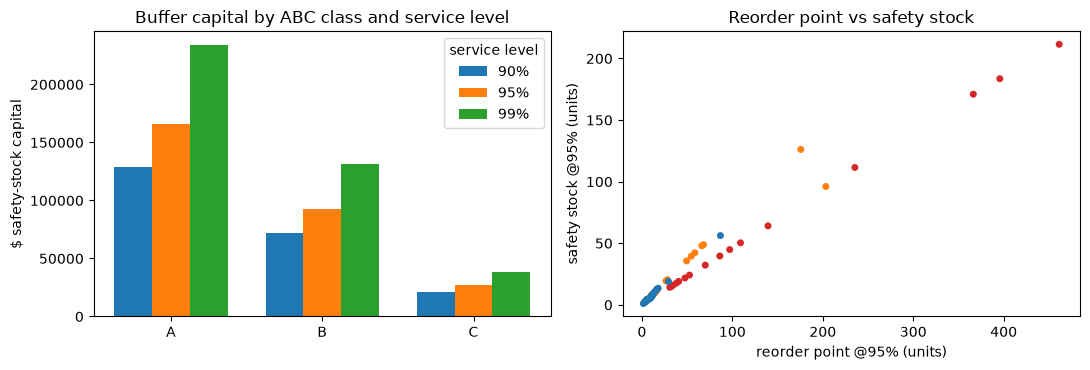

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

order = ["A", "B", "C"]
width = 0.25
for i, lvl in enumerate(["90", "95", "99"]):
    vals = [(l4.loc[l4.abc_class == c, f"safety_stock_{lvl}"] * l4["avg_price"]).sum()
            for c in order]
    ax[0].bar([x + (i - 1) * width for x in range(len(order))], vals, width, label=f"{lvl}%")
ax[0].set_xticks(range(len(order)))
ax[0].set_xticklabels(order)
ax[0].set_ylabel("$ safety-stock capital")
ax[0].set_title("Buffer capital by ABC class and service level")
ax[0].legend(title="service level")

ax[1].scatter(l4["reorder_point_95"], l4["safety_stock_95"], s=16,
              c=l4["abc_class"].map({"A": "tab:red", "B": "tab:orange", "C": "tab:blue"}))
ax[1].set_xlabel("reorder point @95% (units)")
ax[1].set_ylabel("safety stock @95% (units)")
ax[1].set_title("Reorder point vs safety stock")

plt.tight_layout()
plt.show()

### What Layer 4 says

- Catalogue safety-stock working capital: **~$222k at 90%, ~$285k at 95%,
  ~$403k at 99%** service. Moving from 95% to 99% costs ~41% more buffer cash for
  the last 4 points of service.
- **Class A holds the majority of the buffer capital** even though it's 16 SKUs
  — expected, and the reason the mismatch analysis focuses there.
- 33 SKUs (28%) use the class-CV fallback for sigma; their reorder points are
  approximations and are flagged via `sigma_source` so they can be down-weighted
  in the headline number.


## The mismatch analysis — the headline

Layer 1's turnover is algebraically collinear with ABC value, so it can't be the
comparison. Use an independent signal:

    buffer_intensity = safety_stock_value / annual_demand_value

dollars of buffer per dollar of yearly throughput. It's driven by a SKU's demand
coefficient of variation and lead time, **not** its value (rank correlation with
value rank ~ 0), so crossing it against ABC class is meaningful.


In [23]:
from src.inventory import mismatch_analysis

mm = mismatch_analysis(l4)

print("buffer_flag:")
print(mm["buffer_flag"].value_counts())
print()
print("ABC class  x  buffer-intensity tier:")
print(pd.crosstab(mm["abc_class"], mm["buffer_intensity_tier"]))

over = mm[mm["buffer_flag"] == "over_buffered"]
trapped = over["excess_buffer_value"].sum()
a = mm[mm["abc_class"] == "A"]
reinvest = (a["safety_stock_99"] - a["safety_stock_95"]).mul(a["avg_price"]).sum()

print()
print(f"over-buffered SKUs           : {len(over)}  (all class B / C)")
print(f"  safety-stock $ they hold   : ${over['safety_stock_value'].sum():,.0f}")
print(f"  TRAPPED CASH (excess)      : ${trapped:,.0f}")
print(f"cost to lift 16 class-A SKUs 95% -> 99% service : ${reinvest:,.0f}")

buffer_flag:
buffer_flag
efficient        79
over_buffered    39
Name: count, dtype: int64

ABC class  x  buffer-intensity tier:
buffer_intensity_tier  Light  Medium  Heavy
abc_class                                  
A                         16       0      0
B                          1       5     22
C                         23      34     17

over-buffered SKUs           : 39  (all class B / C)
  safety-stock $ they hold   : $94,679
  TRAPPED CASH (excess)      : $27,679
cost to lift 16 class-A SKUs 95% -> 99% service : $68,564


 sku                      product_name abc_class  buffer_intensity  safety_stock_value  excess_buffer_value
1352   Industrial consumer electronics         B          0.024534        10696.046162          2834.723476
1356                     First aid kit         B          0.024631        10451.278559          2799.905973
1354                             DVDs          B          0.025282         8029.064441          2302.423133
1362              Fighting video games         B          0.025097         5015.884765          1411.955383
 303 Garmin Forerunner 910XT GPS Watch         B          0.025427         4271.548192          1242.248197
 208               SOLE E35 Elliptical         B          0.024895         4481.141943          1235.398398
 203 GoPro HERO3+ Black Edition Camera         B          0.025647         3939.327115          1169.681405
1357                   Men's gala suit         B          0.024504         4298.642592          1135.339435
1059       Pelican Maverick 

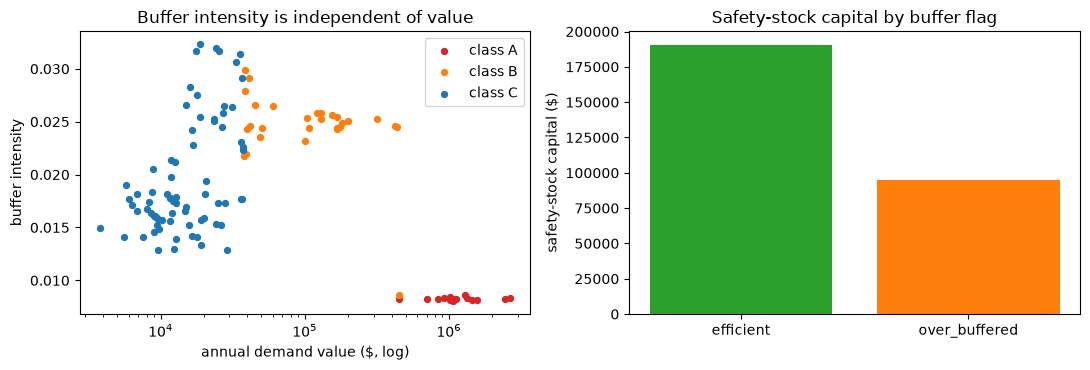

In [24]:
# Where is the trapped cash?
print(over.sort_values("excess_buffer_value", ascending=False)
        [["sku", "product_name", "abc_class", "buffer_intensity",
          "safety_stock_value", "excess_buffer_value"]]
        .head(10).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
colours = {"A": "tab:red", "B": "tab:orange", "C": "tab:blue"}
for cls, g in mm.groupby("abc_class"):
    ax[0].scatter(g["annual_demand_value"], g["buffer_intensity"], s=18,
                  color=colours[cls], label=f"class {cls}")
ax[0].set_xscale("log")
ax[0].set_xlabel("annual demand value ($, log)")
ax[0].set_ylabel("buffer intensity")
ax[0].set_title("Buffer intensity is independent of value")
ax[0].legend()

flag_order = ["efficient", "over_buffered"]
ax[1].bar(flag_order,
          [mm.loc[mm.buffer_flag == f, "safety_stock_value"].sum() for f in flag_order],
          color=["tab:green", "tab:orange"])
ax[1].set_ylabel("safety-stock capital ($)")
ax[1].set_title("Safety-stock capital by buffer flag")
plt.tight_layout()
plt.show()

### What the mismatch analysis says

- **~$28k of safety-stock capital is trapped** — the excess, above a
  median-efficiency buffer for the same throughput, carried by **39 over-buffered
  class B / C SKUs**. That's ~10% of the $285k total safety-stock capital.
- The concentration is in **class B**: 22 of 28 B-SKUs land in the Heavy
  buffer-intensity tier despite B being only 16% of catalogue value. Mid-value,
  lumpy-demand items are the worst offenders — DVDs, first-aid kits, industrial
  electronics.
- **Class A is already efficiently buffered** (all 16 in the Light tier) — high
  volume smooths their demand CV. They are not under-buffered; raising them to
  99% service is a *policy option*, costing ~$69k more in buffer.
- **The reallocation:** freeing the ~$28k trapped in the B/C tail (via demand
  smoothing or shorter lead times — not service cuts) offsets ~40% of the cost of
  lifting every class-A SKU to 99% service. Service level never drops below 95%.


## Sensitivity — service level vs buffer capital

How much safety-stock cash each service level buys, measured against the 95%
baseline, for the catalogue and per ABC class.


In [25]:
from src.inventory import sensitivity_table

sens_all = sensitivity_table(mm)
sens_class = sensitivity_table(mm, by="abc_class")

print("catalogue:")
print(sens_all.round(2).to_string(index=False))
print()
print("by ABC class:")
print(sens_class.round(2).to_string(index=False))

# write a tidy file for the report: class rows + an ALL group
sens_out = pd.concat([sens_all.assign(abc_class="ALL"), sens_class], ignore_index=True)
sens_out = sens_out[["abc_class", "service_level", "z", "safety_stock_units",
                     "buffer_value", "delta_vs_baseline", "pct_vs_baseline"]]
sens_out.to_csv("../outputs/service_level_sensitivity.csv", index=False)
print()
print("wrote", sens_out.shape, "-> outputs/service_level_sensitivity.csv")

catalogue:
 service_level    z  safety_stock_units  buffer_value  delta_vs_baseline  pct_vs_baseline
          0.90 1.28             1689.85     222273.33          -63008.66            -0.22
          0.95 1.64             2168.88     285281.99               0.00             0.00
          0.99 2.33             3067.34     403460.08          118178.09             0.41

by ABC class:
abc_class  service_level    z  safety_stock_units  buffer_value  delta_vs_baseline  pct_vs_baseline
        A           0.90 1.28              807.45     128957.22          -36555.99            -0.22
        A           0.95 1.64             1036.34     165513.20               0.00             0.00
        A           0.99 2.33             1465.64     234077.07           68563.86             0.41
        B           0.90 1.28              497.94      72312.75          -20498.77            -0.22
        B           0.95 1.64              639.09      92811.52               0.00             0.00
        B     

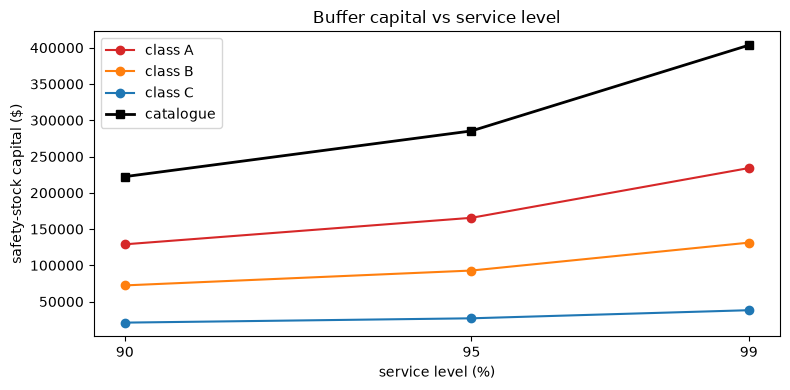

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
colours = {"A": "tab:red", "B": "tab:orange", "C": "tab:blue"}
for cls, g in sens_class.groupby("abc_class"):
    ax.plot(g["service_level"] * 100, g["buffer_value"], marker="o",
            color=colours[cls], label=f"class {cls}")
ax.plot(sens_all["service_level"] * 100, sens_all["buffer_value"], marker="s",
        color="black", linewidth=2, label="catalogue")
ax.set_xlabel("service level (%)")
ax.set_ylabel("safety-stock capital ($)")
ax.set_title("Buffer capital vs service level")
ax.set_xticks([90, 95, 99])
ax.legend()
plt.tight_layout()
plt.show()

### What the sensitivity says

- The **percentage** shift is identical across ABC classes — safety stock scales
  linearly with the z-multiplier, so every class moves **-22% at 90%** and
  **+41% at 99%** relative to the 95% baseline.
- The **dollar** impact is not uniform: class A carries $166k of the $285k
  baseline buffer, so it absorbs most of any catalogue-wide move.
- This is the case for a **class-differentiated policy**: lifting only the 16
  class-A SKUs to 99% costs **+$69k**, versus **+$118k** to lift the whole
  catalogue. Same protection where it matters, 40% cheaper.


## Consolidated output — `sku_metrics.csv`

One row per SKU with the results of every layer, including the `buffer_flag` from
the mismatch analysis. This is the single file the Power BI report reads.


In [27]:
keep = [
    "sku", "product_name", "avg_price", "n_months", "insufficient_history",
    "annual_demand", "annual_demand_value",
    "implied_turns", "implied_days_of_supply", "velocity_tier", "slow_mover",
    "value_rank", "cumulative_pct", "abc_class",
    "eoq", "eoq_orders_per_year", "eoq_cycle_days", "eoq_annual_cost",
    "monthly_annual_cost", "eoq_saving_vs_monthly", "eoq_saving_pct",
    "avg_lead_time_days", "std_lead_time_days",
    "avg_daily_demand", "sigma_daily_demand", "sigma_source",
    "safety_stock_90", "safety_stock_95", "safety_stock_99",
    "reorder_point_90", "reorder_point_95", "reorder_point_99",
    "safety_stock", "reorder_point", "safety_stock_value",
    "buffer_intensity", "buffer_intensity_tier", "buffer_benchmark_value",
    "excess_buffer_value", "buffer_flag",
]
sku_metrics = mm[keep].copy()
sku_metrics.to_csv("../outputs/sku_metrics.csv", index=False)
print("wrote", sku_metrics.shape, "-> outputs/sku_metrics.csv")
sku_metrics.head()

wrote (118, 40) -> outputs/sku_metrics.csv


,sku,product_name,avg_price,n_months,insufficient_history,annual_demand,annual_demand_value,implied_turns,implied_days_of_supply,velocity_tier,...,reorder_point_95,reorder_point_99,safety_stock,reorder_point,safety_stock_value,buffer_intensity,buffer_intensity_tier,buffer_benchmark_value,excess_buffer_value,buffer_flag
0,1351,Dell Laptop,1500.000000,3,True,1768.000000,2.652000e+06,132.966161,2.745059,Fast,...,32.292304,38.414911,14.779976,32.292304,22169.963406,0.008360,Light,47820.860896,0.0,efficient
1,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,34,False,6114.705882,2.445760e+06,127.691298,2.858456,Fast,...,109.003074,129.854179,50.334581,109.003074,20132.826111,0.008232,Light,44101.943731,0.0,efficient
2,365,Perfect Fitness Perfect Rip Deck,59.990002,34,False,26011.058824,1.560403e+06,101.993577,3.578657,Fast,...,461.396123,549.018337,211.520077,461.396123,12689.089795,0.008132,Light,28137.193410,0.0,efficient
3,957,Diamondback Women's Serene Classic Comfort Bi,299.980011,34,False,4845.529412,1.453562e+06,98.439896,3.707846,Fast,...,86.107417,102.539529,39.667127,86.107417,11899.345273,0.008186,Light,26210.627674,0.0,efficient
4,1353,Porcelain crafts,461.480011,2,True,2904.000000,1.340138e+06,94.521178,3.861568,Fast,...,52.623732,62.628908,24.152499,52.623732,11145.895657,0.008317,Light,24165.365981,0.0,efficient
